#  Project 4 — Supply Chain Analytics
## Medallion Architecture + Data Warehouse

**Dataset:** DataCo Supply Chain Dataset (Kaggle)

**Architecture:**
```
🥉 BRONZE  → Raw CSV Data
       ↓
🥈 SILVER  → Python Cleaned & Transformed
       ↓
🥇 GOLD    → PostgreSQL Data Warehouse (Star Schema)
       ↓
📊 REPORTS → Power BI Dashboard
```
 
**Business Questions:**
- Which region has most delays?
- Which product category is most profitable?
- Late delivery rate by shipping mode?
- Which country orders most?

**SQL Techniques:**
-  Window Functions: ROW_NUMBER, RANK, DENSE_RANK, LAG, LEAD
-  Multiple Chained CTEs
-  CASE WHEN Logic
-  PARTITION BY
-  Running Totals / Cumulative Sums
-  Percentile Calculations
-  Star Schema Data Warehouse

##  STEP 1 — Import Libraries

In [5]:
import sys
!{sys.executable} -m pip install psycopg2-binary sqlalchemy pandas numpy matplotlib seaborn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sqlalchemy import create_engine, text, inspect
import psycopg2
from psycopg2.extensions import ISOLATION_LEVEL_AUTOCOMMIT
from datetime import datetime
import os

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-darkgrid')

print(' All libraries imported!')

 All libraries imported!


##  BRONZE LAYER — Raw Data Ingestion

In [4]:
FILE_PATH = 'data/DataCoSupplyChainDataset.csv'
# Load raw data — Bronze Layer
df_bronze = pd.read_csv(FILE_PATH, encoding='latin-1')

print('BRONZE LAYER — Raw Data Loaded!')
print(f'Shape: {df_bronze.shape[0]:,} rows × {df_bronze.shape[1]} columns')
print(f'Memory: {df_bronze.memory_usage().sum() / 1024**2:.1f} MB')

BRONZE LAYER — Raw Data Loaded!
Shape: 180,519 rows × 53 columns
Memory: 73.0 MB


##  STEP 3 — Exploratory Data Analysis

In [8]:
df_bronze.head(3)

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,...,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.25,314.64,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.00,2,Fitness,18.25,-66.04,Pacific Asia,...,1/31/2018 22:56,77202,1360,13.11,0.04,180517,327.75,0.29,1,327.75,314.64,91.25,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.09,311.36,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.00,2,Fitness,18.28,-66.04,Pacific Asia,...,1/13/2018 12:27,75939,1360,16.39,0.05,179254,327.75,-0.80,1,327.75,311.36,-249.09,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.78,309.72,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.00,2,Fitness,37.29,-121.88,Pacific Asia,...,1/13/2018 12:06,75938,1360,18.03,0.06,179253,327.75,-0.80,1,327.75,309.72,-247.78,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class


In [9]:
print("all columns")
for i,col in enumerate(df_bronze.columns,1):
    print(f'  {i}. {col}')

all columns
  1. Type
  2. Days for shipping (real)
  3. Days for shipment (scheduled)
  4. Benefit per order
  5. Sales per customer
  6. Delivery Status
  7. Late_delivery_risk
  8. Category Id
  9. Category Name
  10. Customer City
  11. Customer Country
  12. Customer Email
  13. Customer Fname
  14. Customer Id
  15. Customer Lname
  16. Customer Password
  17. Customer Segment
  18. Customer State
  19. Customer Street
  20. Customer Zipcode
  21. Department Id
  22. Department Name
  23. Latitude
  24. Longitude
  25. Market
  26. Order City
  27. Order Country
  28. Order Customer Id
  29. order date (DateOrders)
  30. Order Id
  31. Order Item Cardprod Id
  32. Order Item Discount
  33. Order Item Discount Rate
  34. Order Item Id
  35. Order Item Product Price
  36. Order Item Profit Ratio
  37. Order Item Quantity
  38. Sales
  39. Order Item Total
  40. Order Profit Per Order
  41. Order Region
  42. Order State
  43. Order Status
  44. Order Zipcode
  45. Product Card Id
 

In [10]:
df_bronze.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [11]:
# Missing values
missing = df_bronze.isnull().sum()
missing_pct = (missing / len(df_bronze)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(' Missing Values:')
print(missing_df)

 Missing Values:
                     Missing Count  Missing %
Product Description         180519     100.00
Order Zipcode               155679      86.24
Customer Lname                   8       0.00
Customer Zipcode                 3       0.00


In [12]:
df_bronze.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,Longitude,Order Customer Id,Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180516.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,24840.00,180519.00,180519.00,0.00,180519.00,180519.00
mean,3.50,2.93,21.97,183.11,0.55,31.85,6691.38,35921.13,5.44,29.72,-84.92,6691.38,36221.89,692.51,20.66,0.10,90260.00,141.23,0.12,2.13,203.77,183.11,21.97,55426.13,692.51,31.85,NaN,141.23,0.00
std,1.62,1.37,104.43,120.04,0.50,15.64,4162.92,37542.46,1.63,9.81,21.43,4162.92,21045.38,336.45,21.80,0.07,52111.49,139.73,0.47,1.45,132.27,120.04,104.43,31919.28,336.45,15.64,NaN,139.73,0.00
min,0.00,0.00,-4274.98,7.49,0.00,2.00,1.00,603.00,2.00,-33.94,-158.03,1.00,1.00,19.00,0.00,0.00,1.00,9.99,-2.75,1.00,9.99,7.49,-4274.98,1040.00,19.00,2.00,NaN,9.99,0.00
25%,2.00,2.00,7.00,104.38,0.00,18.00,3258.50,725.00,4.00,18.27,-98.45,3258.50,18057.00,403.00,5.40,0.04,45130.50,50.00,0.08,1.00,119.98,104.38,7.00,23464.00,403.00,18.00,NaN,50.00,0.00
50%,3.00,4.00,31.52,163.99,1.00,29.00,6457.00,19380.00,5.00,33.14,-76.85,6457.00,36140.00,627.00,14.00,0.10,90260.00,59.99,0.27,1.00,199.92,163.99,31.52,59405.00,627.00,29.00,NaN,59.99,0.00
75%,5.00,4.00,64.80,247.40,1.00,45.00,9779.00,78207.00,7.00,39.28,-66.37,9779.00,54144.00,1004.00,29.99,0.16,135389.50,199.99,0.36,3.00,299.95,247.40,64.80,90008.00,1004.00,45.00,NaN,199.99,0.00
max,6.00,4.00,911.80,1939.99,1.00,76.00,20757.00,99205.00,12.00,48.78,115.26,20757.00,77204.00,1363.00,500.00,0.25,180519.00,1999.99,0.50,5.00,1999.99,1939.99,911.80,99301.00,1363.00,76.00,NaN,1999.99,0.00


##  SILVER LAYER — Cleaned & Transformed Data

In [13]:
df_silver=df_bronze.copy()
print(f'shape{df_silver.shape}')

shape(180519, 53)


In [14]:
# ── 1. Clean column names
df_silver.columns = (
    df_silver.columns
    .str.strip().str.lower()
    .str.replace(' ', '_')
    .str.replace('(', '').str.replace(')', '')
)
print(' Column names cleaned')

 Column names cleaned


In [15]:
# ── 2. Convert dates
date_cols = ['order_date_dateorders', 'shipping_date_dateorders']
for col in date_cols:
    if col in df_silver.columns:
        df_silver[col] = pd.to_datetime(df_silver[col], errors='coerce')
        print(f' Converted: {col}')

 Converted: order_date_dateorders
 Converted: shipping_date_dateorders


In [16]:
# ── 3. Handle missing values
cols_to_drop = [c for c in df_silver.columns if df_silver[c].isnull().mean() > 0.5]
print(f'Dropping high-missing columns: {cols_to_drop}')
df_silver.drop(columns=cols_to_drop, inplace=True)

for col in df_silver.select_dtypes(include=[np.number]).columns:
    if df_silver[col].isnull().sum() > 0:
        df_silver[col].fillna(df_silver[col].median(), inplace=True)

for col in df_silver.select_dtypes(include=['object']).columns:
    if df_silver[col].isnull().sum() > 0:
        df_silver[col].fillna('Unknown', inplace=True)

print(f' Nulls remaining: {df_silver.isnull().sum().sum()}')

Dropping high-missing columns: ['order_zipcode', 'product_description']
 Nulls remaining: 0


In [17]:
# ── 4. Remove duplicates
before = len(df_silver)
df_silver.drop_duplicates(inplace=True)
print(f' Removed {before - len(df_silver):,} duplicates')
print(f'Silver layer shape: {df_silver.shape}')

 Removed 0 duplicates
Silver layer shape: (180519, 51)


In [18]:
# ── 5. Feature Engineering

# Late delivery flag
if 'delivery_status' in df_silver.columns:
    df_silver['is_late_delivery'] = df_silver['delivery_status'].apply(
        lambda x: 1 if 'Late' in str(x) else 0
    )

# Date parts
if 'order_date_dateorders' in df_silver.columns:
    df_silver['order_year']    = df_silver['order_date_dateorders'].dt.year
    df_silver['order_month']   = df_silver['order_date_dateorders'].dt.month
    df_silver['order_quarter'] = df_silver['order_date_dateorders'].dt.quarter

# Profit margin
if 'order_profit_per_order' in df_silver.columns and 'sales' in df_silver.columns:
    df_silver['profit_margin_pct'] = (
        df_silver['order_profit_per_order'] / df_silver['sales'].replace(0, np.nan) * 100
    ).round(2)

# Days delayed
if 'days_for_shipping_real' in df_silver.columns and 'days_for_shipment_scheduled' in df_silver.columns:
    df_silver['days_delayed'] = df_silver['days_for_shipping_real'] - df_silver['days_for_shipment_scheduled']

# Sales segment
if 'sales' in df_silver.columns:
    df_silver['sales_segment'] = pd.cut(
        df_silver['sales'],
        bins=[0, 100, 500, 1000, float('inf')],
        labels=['Low', 'Medium', 'High', 'Premium']
    ).astype(str)

# ETL timestamp
df_silver['etl_loaded_at'] = datetime.now()

print(' Silver Layer — Feature Engineering Done!')
print(f'Final shape: {df_silver.shape}')

 Silver Layer — Feature Engineering Done!
Final shape: (180519, 59)


In [19]:
df_silver.head(3)

,type,days_for_shipping_real,days_for_shipment_scheduled,benefit_per_order,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_city,customer_country,customer_email,customer_fname,customer_id,customer_lname,customer_password,customer_segment,customer_state,customer_street,customer_zipcode,department_id,department_name,latitude,longitude,market,...,order_item_product_price,order_item_profit_ratio,order_item_quantity,sales,order_item_total,order_profit_per_order,order_region,order_state,order_status,product_card_id,product_category_id,product_image,product_name,product_price,product_status,shipping_date_dateorders,shipping_mode,is_late_delivery,order_year,order_month,order_quarter,profit_margin_pct,days_delayed,sales_segment,etl_loaded_at
0,DEBIT,3,4,91.25,314.64,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.00,2,Fitness,18.25,-66.04,Pacific Asia,...,327.75,0.29,1,327.75,314.64,91.25,Southeast Asia,Java Occidental,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-02-03 22:56:00,Standard Class,0,2018,1,1,27.84,-1,Medium,2026-06-03 20:53:12.837483
1,TRANSFER,5,4,-249.09,311.36,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.00,2,Fitness,18.28,-66.04,Pacific Asia,...,327.75,-0.80,1,327.75,311.36,-249.09,South Asia,Rajastán,PENDING,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-18 12:27:00,Standard Class,1,2018,1,1,-76.00,1,Medium,2026-06-03 20:53:12.837483
2,CASH,4,4,-247.78,309.72,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.00,2,Fitness,37.29,-121.88,Pacific Asia,...,327.75,-0.80,1,327.75,309.72,-247.78,South Asia,Rajastán,CLOSED,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-17 12:06:00,Standard Class,0,2018,1,1,-75.60,0,Medium,2026-06-03 20:53:12.837483


##  STEP 5 — Visualizations

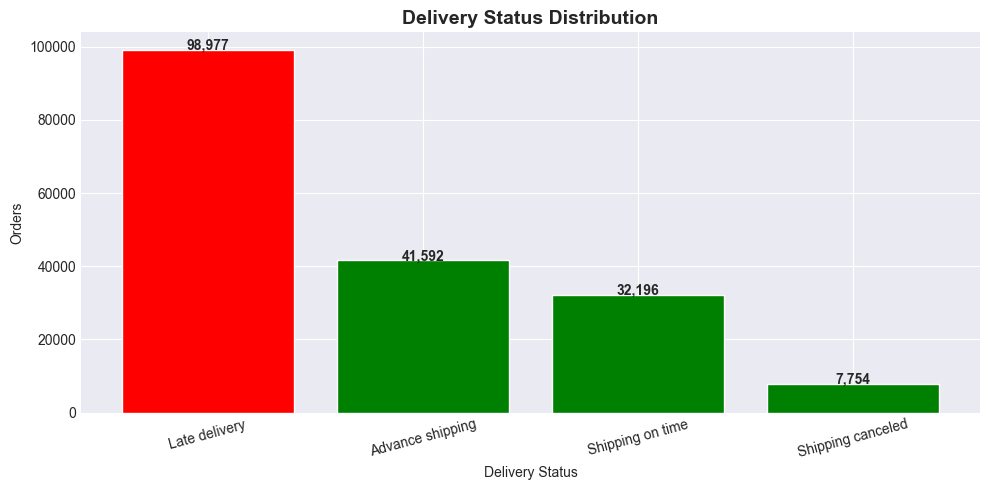

 Chart 1 saved!


In [20]:
# Chart 1: Delivery Status
if 'delivery_status' in df_silver.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    counts = df_silver['delivery_status'].value_counts()
    colors = ['red' if 'Late' in str(x) else 'green' for x in counts.index]
    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f'{val:,}', ha='center', fontsize=10, fontweight='bold')
    ax.set_title('Delivery Status Distribution', fontsize=14, fontweight='bold')
    ax.set_xlabel('Delivery Status')
    ax.set_ylabel('Orders')
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig('chart1_delivery_status.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(' Chart 1 saved!')

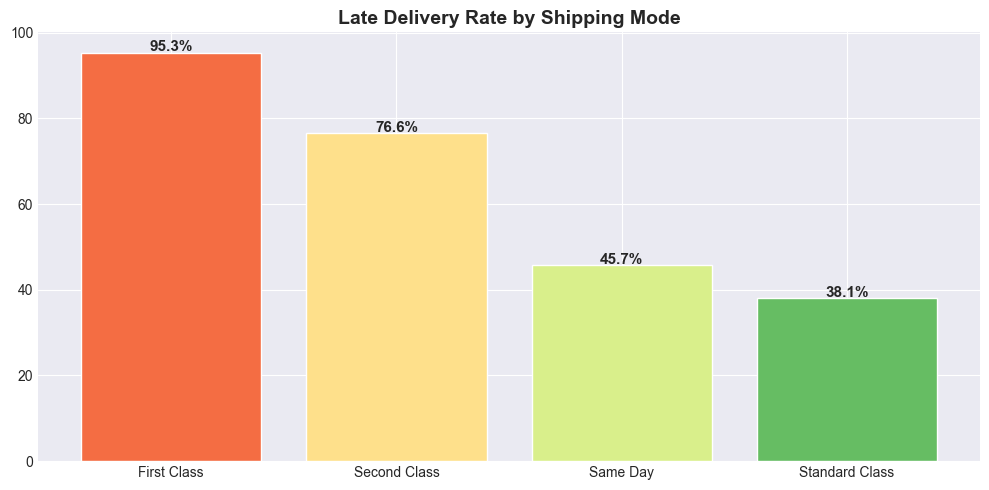

 Chart 2 saved!


In [21]:
# Chart 2: Late Rate by Shipping Mode
ship_col = next((c for c in df_silver.columns if 'ship' in c and 'mode' in c), None)
if ship_col and 'is_late_delivery' in df_silver.columns:
    late_rate = df_silver.groupby(ship_col)['is_late_delivery'].mean() * 100
    late_rate = late_rate.sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(late_rate)))
    bars = ax.bar(late_rate.index, late_rate.values, color=colors, edgecolor='white')
    for bar, val in zip(bars, late_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
    ax.set_title('Late Delivery Rate by Shipping Mode', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('chart2_late_by_shipping.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(' Chart 2 saved!')

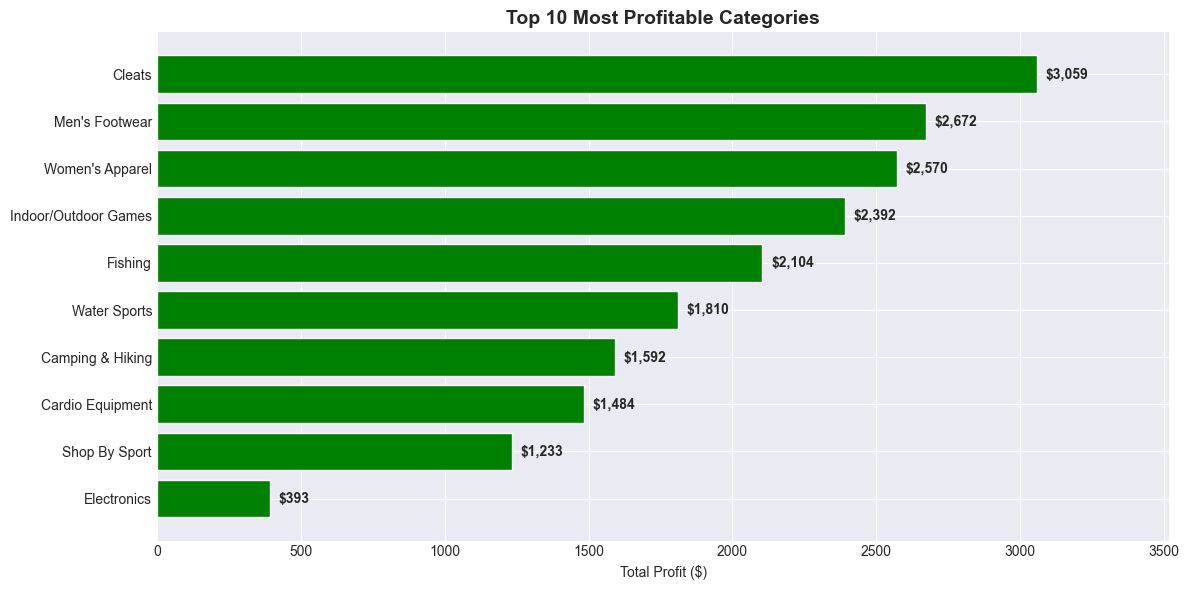

 Chart 3 saved!


In [22]:
# Chart 3: Top 10 Profitable Categories
cat_col    = next((c for c in df_silver.columns if 'category' in c and 'name' in c), None)
profit_col = next((c for c in df_silver.columns if 'profit' in c and 'order' in c), None)
if cat_col and profit_col:
    cat_profit = df_silver.groupby(cat_col)[profit_col].sum().sort_values(ascending=False).head(10)
    fig, ax = plt.subplots(figsize=(12, 6))
    colors = ['green' if v > 0 else 'red' for v in cat_profit.values]
    bars=ax.barh(cat_profit.index, cat_profit.values, color=colors, edgecolor='white')
    for barh, val in zip(bars, cat_profit.values):
        ax.text(
        barh.get_width() + 30,
        barh.get_y() + barh.get_height()/2,
        f'${val:,.0f}',
        va='center',
        ha='left',
        fontweight='bold'
    )
    ax.set_xlim(0, cat_profit.max() * 1.15)
    ax.invert_yaxis()
    ax.set_title('Top 10 Most Profitable Categories', fontsize=14, fontweight='bold')
    ax.set_xlabel('Total Profit ($)')
    plt.tight_layout()
    plt.savefig('chart3_category_profit.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(' Chart 3 saved!')

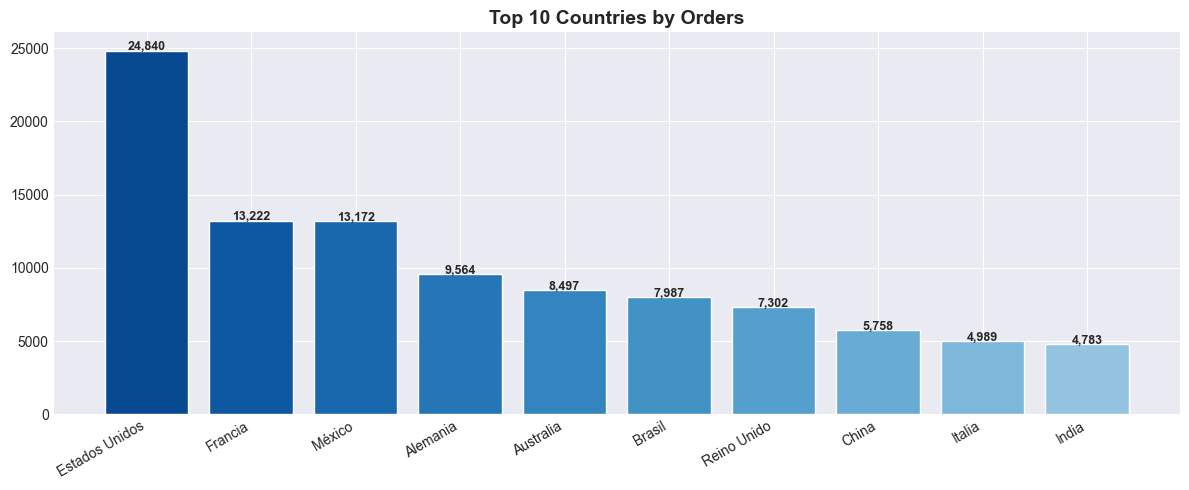

 Chart 4 saved!


In [23]:
# Chart 4: Top 10 Countries
country_col = next((c for c in df_silver.columns if 'country' in c and 'order' in c), None)
if not country_col:
    country_col = next((c for c in df_silver.columns if 'country' in c), None)
if country_col:
    top_countries = df_silver[country_col].value_counts().head(10)
    fig, ax = plt.subplots(figsize=(12, 5))
    colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_countries))[::-1])
    bars = ax.bar(top_countries.index, top_countries.values, color=colors, edgecolor='white')
    for bar, val in zip(bars, top_countries.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                f'{val:,}', ha='center', fontsize=9, fontweight='bold')
    ax.set_title('Top 10 Countries by Orders', fontsize=14, fontweight='bold')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig('chart4_top_countries.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(' Chart 4 saved!')

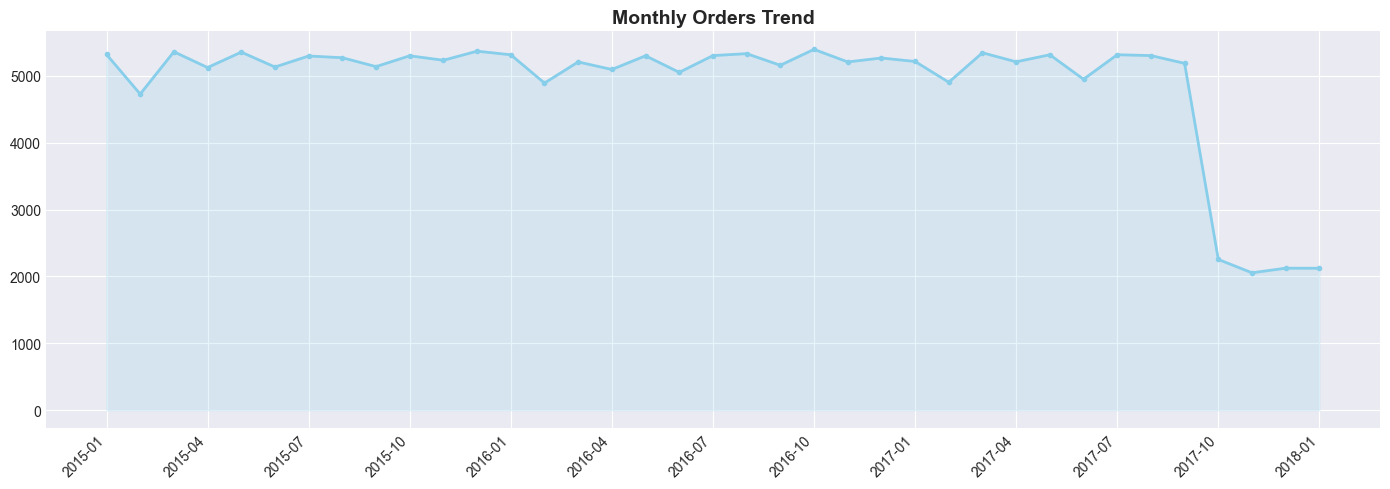

Chart 5 saved!


In [24]:
# Chart 5: Monthly Trend
if 'order_year' in df_silver.columns:
    monthly = df_silver.groupby(['order_year','order_month']).size().reset_index(name='orders')
    monthly['period'] = monthly['order_year'].astype(str) + '-' + monthly['order_month'].astype(str).str.zfill(2)
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(monthly['period'], monthly['orders'], color='skyblue', linewidth=2, marker='o', markersize=3)
    ax.fill_between(monthly['period'], monthly['orders'], alpha=0.2, color='skyblue')
    ax.set_title('Monthly Orders Trend', fontsize=14, fontweight='bold')
    step = max(1, len(monthly) // 12)
    ax.set_xticks(monthly['period'][::step])
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('chart5_monthly_trend.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Chart 5 saved!')

##  STEP 6 — PostgreSQL Setup

In [ ]:
DB_CONFIG = {
    'host'    : 'localhost',
    'port'    : '5432',
    'database': 'supply_chain_dw',   # DW = Data Warehouse
    'user'    : 'your username',
    'password': 'your password'  #  Change this!
}
print(' DB Config ready. Update password!')

 DB Config ready. Update password!


In [6]:
# Create database
try:
    conn = psycopg2.connect(
        host=DB_CONFIG['host'], port=DB_CONFIG['port'],
        database='postgres',
        user=DB_CONFIG['user'], password=DB_CONFIG['password']
    )
    conn.set_isolation_level(ISOLATION_LEVEL_AUTOCOMMIT)
    cur = conn.cursor()
    cur.execute(f"SELECT 1 FROM pg_database WHERE datname = '{DB_CONFIG['database']}'")
    if not cur.fetchone():
        cur.execute(f"CREATE DATABASE {DB_CONFIG['database']}")
        print(f" Database '{DB_CONFIG['database']}' created!")
    else:
        print(f" Database '{DB_CONFIG['database']}' already exists!")
    cur.close(); conn.close()
except Exception as e:
    print(f'Error: {e}')

 Database 'supply_chain_dw' already exists!


In [7]:
# Create engine
try:
    engine = create_engine(
        f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_CONFIG['password']}"
        f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"
    )
    with engine.connect() as c:
        print(' PostgreSQL connected!')
except Exception as e:
    print(f' Connection failed: {e}')

 PostgreSQL connected!


##  GOLD LAYER — Data Warehouse (Star Schema)

In [28]:
print(' Building GOLD Layer — Data Warehouse')
print('=' * 50)
print('Creating Star Schema:')
print('  → Fact_Orders (main fact table)')
print('  → Dim_Customer')
print('  → Dim_Product')
print('  → Dim_Region')
print('  → Dim_Shipping')
print('  → Dim_Date')
print('=' * 50)

 Building GOLD Layer — Data Warehouse
Creating Star Schema:
  → Fact_Orders (main fact table)
  → Dim_Customer
  → Dim_Product
  → Dim_Region
  → Dim_Shipping
  → Dim_Date


In [29]:
# ── Dim_Customer
customer_cols = [c for c in df_silver.columns if 'customer' in c.lower()]
customer_cols += [c for c in df_silver.columns if 'country' in c.lower() or 'market' in c.lower()]
customer_cols = list(set(customer_cols))

dim_customer = df_silver[customer_cols].drop_duplicates().reset_index(drop=True)
dim_customer['customer_key'] = dim_customer.index + 1

dim_customer.to_sql('dim_customer', engine, if_exists='replace', index=False)
print(f' Dim_Customer loaded: {len(dim_customer):,} rows')


 Dim_Customer loaded: 180,327 rows


In [30]:
# ── Dim_Product
product_cols = [c for c in df_silver.columns 
                if any(x in c.lower() for x in ['product', 'category', 'department'])]
product_cols = list(set(product_cols))

dim_product = df_silver[product_cols].drop_duplicates().reset_index(drop=True)
dim_product['product_key'] = dim_product.index + 1

dim_product.to_sql('dim_product', engine, if_exists='replace', index=False)
print(f' Dim_Product loaded: {len(dim_product):,} rows')

 Dim_Product loaded: 118 rows


In [31]:
# ── Dim_Region
region_cols = [c for c in df_silver.columns 
               if any(x in c.lower() for x in ['region', 'country', 'city', 'state', 'market'])]
region_cols = list(set(region_cols))

dim_region = df_silver[region_cols].drop_duplicates().reset_index(drop=True)
dim_region['region_key'] = dim_region.index + 1

dim_region.to_sql('dim_region', engine, if_exists='replace', index=False)
print(f' Dim_Region loaded: {len(dim_region):,} rows')

 Dim_Region loaded: 39,531 rows


In [32]:
# ── Dim_Shipping
shipping_cols = [c for c in df_silver.columns 
                 if any(x in c.lower() for x in ['ship', 'delivery', 'days'])]
shipping_cols = list(set(shipping_cols))

dim_shipping = df_silver[shipping_cols].drop_duplicates().reset_index(drop=True)
dim_shipping['shipping_key'] = dim_shipping.index + 1

dim_shipping.to_sql('dim_shipping', engine, if_exists='replace', index=False)
print(f' Dim_Shipping loaded: {len(dim_shipping):,} rows')

 Dim_Shipping loaded: 65,752 rows


In [33]:
# ── Dim_Date
if 'order_date_dateorders' in df_silver.columns:
    dim_date = pd.DataFrame({
        'date'         : df_silver['order_date_dateorders'].dt.date,
        'year'         : df_silver['order_year'],
        'month'        : df_silver['order_month'],
        'quarter'      : df_silver['order_quarter'],
        'month_name'   : df_silver['order_date_dateorders'].dt.strftime('%B'),
        'day_of_week'  : df_silver['order_date_dateorders'].dt.dayofweek,
        'day_name'     : df_silver['order_date_dateorders'].dt.strftime('%A'),
        'is_weekend'   : df_silver['order_date_dateorders'].dt.dayofweek.isin([5,6]).astype(int)
    }).drop_duplicates().reset_index(drop=True)
    dim_date['date_key'] = dim_date.index + 1

    dim_date.to_sql('dim_date', engine, if_exists='replace', index=False)
    print(f' Dim_Date loaded: {len(dim_date):,} rows')

 Dim_Date loaded: 1,127 rows


In [34]:
# ── Fact_Orders (Main Fact Table)
fact_cols = [
    c for c in df_silver.columns
    if any(x in c.lower() for x in [
        'order_id', 'sales', 'profit', 'quantity',
        'discount', 'is_late', 'days_delayed',
        'profit_margin', 'order_date', 'order_year',
        'order_month', 'order_quarter', 'sales_segment',
        'etl_loaded',
          # Foreign key columns for Power BI relationships
        'customer_id', 'product_card_id', 'order_region', 'shipping_mode'
    ])
]
fact_cols = list(set(fact_cols))

fact_orders = df_silver[fact_cols].copy()

fact_orders.to_sql('fact_orders', engine, if_exists='replace', index=False, chunksize=1000)
print(f' Fact_Orders loaded: {len(fact_orders):,} rows')

 Fact_Orders loaded: 180,519 rows


In [35]:
# ── Also load full silver table
df_silver.to_sql('supply_chain', engine, if_exists='replace', index=False, chunksize=10000)
print(f' Silver table loaded: {len(df_silver):,} rows')

# Verify all tables
with engine.connect() as conn:
    tables = ['supply_chain', 'fact_orders', 'dim_customer',
              'dim_product', 'dim_region', 'dim_shipping', 'dim_date']
    print('\n GOLD LAYER — Data Warehouse Tables:')
    print('=' * 45)
    for table in tables:
        try:
            count = conn.execute(text(f'SELECT COUNT(*) FROM {table}')).fetchone()[0]
            print(f'   {table:<20} : {count:,} rows')
        except:
            print(f'   {table} not found')
    print('=' * 45)

 Silver table loaded: 180,519 rows

 GOLD LAYER — Data Warehouse Tables:
   supply_chain         : 180,519 rows
   fact_orders          : 180,519 rows
   dim_customer         : 180,327 rows
   dim_product          : 118 rows
   dim_region           : 39,531 rows
   dim_shipping         : 65,752 rows
   dim_date             : 1,127 rows


In [36]:
inspector = inspect(engine)
for table in ['fact_orders', 'dim_customer', 'dim_product', 'dim_region', 'dim_shipping']:
    cols = [c['name'] for c in inspector.get_columns(table)]
    print(f"{table}: {cols}")

fact_orders: ['order_item_quantity', 'order_customer_id', 'is_late_delivery', 'sales_per_customer', 'order_id', 'days_delayed', 'order_date_dateorders', 'order_year', 'order_item_discount', 'order_quarter', 'product_card_id', 'shipping_mode', 'order_month', 'order_region', 'order_item_discount_rate', 'sales', 'order_item_profit_ratio', 'profit_margin_pct', 'order_profit_per_order', 'etl_loaded_at', 'customer_id', 'sales_segment']
dim_customer: ['customer_id', 'order_customer_id', 'customer_fname', 'customer_password', 'customer_state', 'sales_per_customer', 'customer_lname', 'market', 'customer_email', 'customer_street', 'customer_city', 'customer_segment', 'customer_country', 'customer_zipcode', 'order_country', 'customer_key']
dim_product: ['product_name', 'product_price', 'product_image', 'product_status', 'order_item_product_price', 'department_name', 'product_card_id', 'product_category_id', 'category_id', 'category_name', 'department_id', 'product_key']
dim_region: ['customer_sta

##  STEP 7 — Advanced SQL Queries (15 Queries)

In [37]:
# Helper function
def run_query(title, sql, engine, show_rows=15):
    print(f'\n{"="*60}')
    print(f'  {title}')
    print(f'{"="*60}')
    result = pd.read_sql(sql, engine)
    display(result.head(show_rows))
    return result

print(' Helper function ready!')

 Helper function ready!


In [38]:
# QUERY 1: RANK Products by Profit Within Each Region
# Techniques: CTE + RANK() + PARTITION BY
q1 = """
WITH regional_product_profit AS (
    SELECT
        order_region,
        category_name,
        COUNT(*)                                          AS total_orders,
        ROUND(SUM(order_profit_per_order)::numeric, 2)   AS total_profit,
        ROUND(AVG(order_profit_per_order)::numeric, 2)   AS avg_profit
    FROM supply_chain
    GROUP BY order_region, category_name
),
ranked AS (
    SELECT
        order_region,
        category_name,
        total_orders,
        total_profit,
        avg_profit,
        RANK()       OVER (PARTITION BY order_region ORDER BY total_profit DESC) AS profit_rank,
        DENSE_RANK() OVER (PARTITION BY order_region ORDER BY total_profit DESC) AS dense_rank
    FROM regional_product_profit
)
SELECT * FROM ranked
WHERE profit_rank <= 3
ORDER BY order_region, profit_rank;
"""
r1 = run_query('QUERY 1 — Top 3 Products by Profit in Each Region (RANK + PARTITION BY)', q1, engine)


  QUERY 1 — Top 3 Products by Profit in Each Region (RANK + PARTITION BY)


,order_region,category_name,total_orders,total_profit,avg_profit,profit_rank,dense_rank
0,Canada,Fishing,69,6567.47,95.18,1,1
1,Canada,Cardio Equipment,76,3477.36,45.75,2,2
2,Canada,Cleats,145,3206.88,22.12,3,3
3,Caribbean,Fishing,827,29860.44,36.11,1,1
4,Caribbean,Cleats,1199,28157.29,23.48,2,2
5,Caribbean,Cardio Equipment,635,22909.27,36.08,3,3
6,Central Africa,Cardio Equipment,115,6275.32,54.57,1,1
7,Central Africa,Cleats,241,5003.84,20.76,2,2
8,Central Africa,Fishing,168,4459.01,26.54,3,3
9,Central America,Fishing,2822,134268.20,47.58,1,1


In [39]:
# QUERY 2: Running Cumulative Sales
# Techniques: CTE + SUM() OVER
q2 = """
WITH monthly_sales AS (
    SELECT
        order_year,
        order_month,
        COUNT(*)                                       AS total_orders,
        ROUND(SUM(sales)::numeric, 2)                  AS monthly_sales,
        ROUND(SUM(order_profit_per_order)::numeric, 2) AS monthly_profit
    FROM supply_chain
    GROUP BY order_year, order_month
)
SELECT
    order_year,
    order_month,
    total_orders,
    monthly_sales,
    monthly_profit,
    ROUND(SUM(monthly_sales) OVER (
        PARTITION BY order_year
        ORDER BY order_month
    )::numeric, 2) AS cumulative_sales_ytd,
    ROUND(SUM(monthly_sales) OVER (
        ORDER BY order_year, order_month
    )::numeric, 2) AS running_total_all_time
FROM monthly_sales
ORDER BY order_year, order_month;
"""
r2 = run_query('QUERY 2 — Running Cumulative Sales (YTD + All Time)', q2, engine)


  QUERY 2 — Running Cumulative Sales (YTD + All Time)


,order_year,order_month,total_orders,monthly_sales,monthly_profit,cumulative_sales_ytd,running_total_all_time
0,2015,1,5322,1051590.08,111660.74,1051590.08,1051590.08
1,2015,2,4729,927009.90,99140.66,1978599.98,1978599.98
2,2015,3,5362,1051253.69,113778.21,3029853.67,3029853.67
3,2015,4,5126,1014463.28,108083.68,4044316.95,4044316.95
4,2015,5,5357,1050478.44,112147.90,5094795.39,5094795.39
5,2015,6,5134,1024006.17,110147.16,6118801.56,6118801.56
6,2015,7,5299,1038081.19,115624.06,7156882.75,7156882.75
7,2015,8,5273,1029494.69,117979.77,8186377.44,8186377.44
8,2015,9,5140,1018338.60,113467.94,9204716.04,9204716.04
9,2015,10,5302,1049154.27,101757.87,10253870.31,10253870.31


In [40]:
# QUERY 3: Top 3 Late Regions Per Shipping Mode
# Techniques: Multi-CTE + ROW_NUMBER
q3 = """
WITH base AS (
    SELECT
        shipping_mode,
        order_region,
        COUNT(*)                              AS total_orders,
        SUM(is_late_delivery)                 AS late_orders,
        ROUND(AVG(is_late_delivery)*100, 2)   AS late_rate_pct
    FROM supply_chain
    GROUP BY shipping_mode, order_region
),
ranked AS (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY shipping_mode
            ORDER BY late_rate_pct DESC
        ) AS rn
    FROM base
)
SELECT shipping_mode, rn AS rank_within_mode,
       order_region, total_orders, late_orders, late_rate_pct
FROM ranked
WHERE rn <= 3
ORDER BY shipping_mode, rn;
"""
r3 = run_query('QUERY 3 — Top 3 Late Regions Per Shipping Mode (ROW_NUMBER)', q3, engine)


  QUERY 3 — Top 3 Late Regions Per Shipping Mode (ROW_NUMBER)


,shipping_mode,rank_within_mode,order_region,total_orders,late_orders,late_rate_pct
0,First Class,1,Central Asia,63,63.00,100.00
1,First Class,2,East Africa,280,277.00,98.93
2,First Class,3,Southern Africa,198,195.00,98.48
3,Same Day,1,Southern Africa,75,42.00,56.00
4,Same Day,2,North Africa,193,108.00,55.96
5,Same Day,3,Southern Europe,569,303.00,53.25
6,Second Class,1,Central Asia,117,101.00,86.32
7,Second Class,2,South of USA,829,673.00,81.18
8,Second Class,3,Central Africa,297,241.00,81.14
9,Standard Class,1,Central Africa,1001,429.00,42.86


In [41]:
# QUERY 4: Detect Delay Spikes Using LAG/LEAD
# Techniques: CTE + LAG() + LEAD() + CASE WHEN
q4 = """
WITH monthly_delays AS (
    SELECT
        order_year,
        order_month,
        COUNT(*)                            AS total_orders,
        ROUND(AVG(is_late_delivery)*100, 2) AS late_rate_pct
    FROM supply_chain
    GROUP BY order_year, order_month
),
with_lag_lead AS (
    SELECT *,
        LAG(late_rate_pct)  OVER (ORDER BY order_year, order_month) AS prev_month_late_rate,
        LEAD(late_rate_pct) OVER (ORDER BY order_year, order_month) AS next_month_late_rate
    FROM monthly_delays
)
SELECT
    order_year, order_month,
    late_rate_pct, prev_month_late_rate,
    ROUND((late_rate_pct - prev_month_late_rate)::numeric, 2) AS mom_change,
    CASE
        WHEN (late_rate_pct - prev_month_late_rate) > 5  THEN ' SPIKE'
        WHEN (late_rate_pct - prev_month_late_rate) < -5 THEN ' IMPROVED'
        WHEN prev_month_late_rate IS NULL                THEN ' First Month'
        ELSE                                                  ' Normal'
    END AS delay_trend_flag
FROM with_lag_lead
ORDER BY order_year, order_month;
"""
r4 = run_query('QUERY 4 — Delay Spikes via LAG/LEAD + CASE WHEN', q4, engine)


  QUERY 4 — Delay Spikes via LAG/LEAD + CASE WHEN


,order_year,order_month,late_rate_pct,prev_month_late_rate,mom_change,delay_trend_flag
0,2015,1,54.11,NaN,NaN,First Month
1,2015,2,54.85,54.11,0.74,Normal
2,2015,3,54.76,54.85,-0.09,Normal
3,2015,4,53.84,54.76,-0.92,Normal
4,2015,5,55.09,53.84,1.25,Normal
5,2015,6,54.11,55.09,-0.98,Normal
6,2015,7,55.46,54.11,1.35,Normal
7,2015,8,55.68,55.46,0.22,Normal
8,2015,9,56.69,55.68,1.01,Normal
9,2015,10,54.81,56.69,-1.88,Normal


In [42]:
# QUERY 5: Customer Segment Profitability
# Techniques: CASE WHEN + RANK + PARTITION BY
q5 = """
WITH segmented AS (
    SELECT
        customer_segment, market,
        COUNT(*)                                           AS total_orders,
        ROUND(SUM(sales)::numeric, 2)                      AS total_sales,
        ROUND(SUM(order_profit_per_order)::numeric, 2)     AS total_profit,
        ROUND(AVG(is_late_delivery)*100, 2)                AS late_rate_pct,
        CASE
            WHEN SUM(order_profit_per_order) > 500000 THEN 'Platinum'
            WHEN SUM(order_profit_per_order) > 200000 THEN 'Gold'
            WHEN SUM(order_profit_per_order) > 50000  THEN 'Silver'
            ELSE 'Bronze'
        END AS profit_tier
    FROM supply_chain
    GROUP BY customer_segment, market
)
SELECT *,
    RANK() OVER (PARTITION BY market ORDER BY total_profit DESC) AS rank_in_market,
    RANK() OVER (ORDER BY total_profit DESC)                     AS overall_rank
FROM segmented
ORDER BY overall_rank;
"""
r5 = run_query('QUERY 5 — Customer Segment Profitability (CASE WHEN + RANK)', q5, engine)


  QUERY 5 — Customer Segment Profitability (CASE WHEN + RANK)


,customer_segment,market,total_orders,total_sales,total_profit,late_rate_pct,profit_tier,rank_in_market,overall_rank
0,Consumer,Europe,26108,5671565.35,627099.00,55.64,Platinum,1,1
1,Consumer,LATAM,26598,5289638.78,568246.21,54.61,Platinum,1,2
2,Consumer,Pacific Asia,21284,4286860.71,445629.43,54.46,Gold,1,3
3,Corporate,Europe,15313,3303070.67,355412.12,54.14,Gold,2,4
4,Corporate,LATAM,15699,3139114.84,350573.82,53.84,Gold,2,5
5,Consumer,USCA,13507,2660291.21,302912.14,54.04,Gold,1,6
6,Corporate,Pacific Asia,12508,2515592.59,258109.51,56.05,Gold,2,7
7,Home Office,LATAM,9297,1848859.22,204501.58,54.49,Gold,3,8
8,Home Office,Europe,8831,1897760.77,186931.84,55.78,Silver,3,9
9,Corporate,USCA,7741,1510871.23,162718.14,55.35,Silver,2,10


In [43]:
# QUERY 6: Sales Percentile Distribution
# Techniques: PERCENTILE_CONT + CTE
q6 = """
WITH category_stats AS (
    SELECT
        category_name,
        COUNT(*)                                                         AS total_orders,
        ROUND(AVG(sales)::numeric, 2)                                    AS avg_sales,
        ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY sales)::numeric, 2) AS p25,
        ROUND(PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY sales)::numeric, 2) AS median_sales,
        ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY sales)::numeric, 2) AS p75,
        ROUND(PERCENTILE_CONT(0.90) WITHIN GROUP (ORDER BY sales)::numeric, 2) AS p90
    FROM supply_chain
    GROUP BY category_name
)
SELECT * FROM category_stats
ORDER BY median_sales DESC;
"""
r6 = run_query('QUERY 6 — Sales Percentile Distribution (PERCENTILE_CONT)', q6, engine)


  QUERY 6 — Sales Percentile Distribution (PERCENTILE_CONT)


,category_name,total_orders,avg_sales,p25,median_sales,p75,p90
0,Computers,442,1500.00,1500.00,1500.00,1500.00,1500.00
1,Garden,484,532.58,532.58,532.58,532.58,532.58
2,Crafts,484,461.48,461.48,461.48,461.48,461.48
3,Cameras,592,452.04,452.04,452.04,452.04,452.04
4,Fishing,17325,399.98,399.98,399.98,399.98,399.98
5,Children's Clothing,652,357.10,357.10,357.10,357.10,357.10
6,Sporting Goods,357,327.75,327.75,327.75,327.75,327.75
7,Basketball,67,404.47,299.99,299.99,299.99,999.99
8,Camping & Hiking,13729,299.98,299.98,299.98,299.98,299.98
9,As Seen on TV!,68,302.91,199.98,299.97,399.96,499.95


In [44]:
# QUERY 7: Month-over-Month Growth
# Techniques: CTE + LAG + CASE WHEN
q7 = """
WITH monthly AS (
    SELECT order_year, order_month,
        ROUND(SUM(sales)::numeric, 2) AS monthly_sales
    FROM supply_chain
    GROUP BY order_year, order_month
),
with_growth AS (
    SELECT *,
        LAG(monthly_sales) OVER (ORDER BY order_year, order_month) AS prev_month_sales
    FROM monthly
)
SELECT
    order_year, order_month,
    monthly_sales, prev_month_sales,
    ROUND(((monthly_sales - prev_month_sales) /
           NULLIF(prev_month_sales, 0) * 100)::numeric, 2) AS mom_growth_pct,
    CASE
        WHEN monthly_sales > prev_month_sales THEN 'Growth'
        WHEN monthly_sales < prev_month_sales THEN 'Decline'
        WHEN prev_month_sales IS NULL         THEN 'Baseline'
        ELSE ' Flat'
    END AS growth_flag
FROM with_growth
ORDER BY order_year, order_month;
"""
r7 = run_query('QUERY 7 — Month-over-Month Growth (LAG + CASE WHEN)', q7, engine)


  QUERY 7 — Month-over-Month Growth (LAG + CASE WHEN)


,order_year,order_month,monthly_sales,prev_month_sales,mom_growth_pct,growth_flag
0,2015,1,1051590.08,NaN,NaN,Baseline
1,2015,2,927009.90,1051590.08,-11.85,Decline
2,2015,3,1051253.69,927009.90,13.40,Growth
3,2015,4,1014463.28,1051253.69,-3.50,Decline
4,2015,5,1050478.44,1014463.28,3.55,Growth
5,2015,6,1024006.17,1050478.44,-2.52,Decline
6,2015,7,1038081.19,1024006.17,1.37,Growth
7,2015,8,1029494.69,1038081.19,-0.83,Decline
8,2015,9,1018338.60,1029494.69,-1.08,Decline
9,2015,10,1049154.27,1018338.60,3.03,Growth


In [45]:
# QUERY 8: Market Performance Dashboard
q8 = """
WITH market_metrics AS (
    SELECT
        market,
        COUNT(DISTINCT order_country)                  AS countries_served,
        COUNT(*)                                       AS total_orders,
        ROUND(SUM(sales)::numeric, 2)                  AS total_sales,
        ROUND(SUM(order_profit_per_order)::numeric, 2) AS total_profit,
        ROUND(AVG(is_late_delivery)*100 ::numeric, 2)            AS late_delivery_pct,
        ROUND(
        (SUM(order_profit_per_order) /
              NULLIF(SUM(sales), 0) * 100)::numeric, 2)          AS profit_margin_pct
    FROM supply_chain
    GROUP BY market
)
SELECT *,
    RANK() OVER (ORDER BY total_profit DESC)      AS profit_rank,
    RANK() OVER (ORDER BY late_delivery_pct ASC)  AS best_delivery_rank
FROM market_metrics
ORDER BY profit_rank;
"""
r8 = run_query('QUERY 8 — Market Performance Dashboard', q8, engine)


  QUERY 8 — Market Performance Dashboard


,market,countries_served,total_orders,total_sales,total_profit,late_delivery_pct,profit_margin_pct,profit_rank,best_delivery_rank
0,Europe,37,50252,10872396.80,1169442.96,55.21,10.76,1,5
1,LATAM,29,51594,10277612.84,1123321.61,54.36,10.93,2,1
2,Pacific Asia,47,41260,8273743.74,857753.44,55.05,10.37,3,4
3,USCA,2,25799,5066528.71,564313.78,54.80,11.14,4,3
4,Africa,49,11614,2294452.93,252071.18,54.59,10.99,5,2


In [46]:
# QUERY 9: Products with Consistent Loss
# Techniques: Subquery in CTE + HAVING
q9 = """
WITH product_yearly AS (
    SELECT product_name, order_year,
        ROUND(SUM(order_profit_per_order)::numeric, 2) AS yearly_profit
    FROM supply_chain
    GROUP BY product_name, order_year
),
loss_years AS (
    SELECT product_name,
        COUNT(*)                                           AS years_tracked,
        SUM(CASE WHEN yearly_profit < 0 THEN 1 ELSE 0 END) AS loss_years_count,
        ROUND(SUM(yearly_profit)::numeric, 2)              AS total_profit
    FROM product_yearly
    GROUP BY product_name
    HAVING SUM(CASE WHEN yearly_profit < 0 THEN 1 ELSE 0 END) >= 1
)
SELECT *,
    CASE
        WHEN loss_years_count = years_tracked THEN 'Always Losing'
        WHEN loss_years_count >= 2          THEN 'Mostly Losing'
        ELSE                                       'Sometimes Losing'
    END AS risk_label
FROM loss_years
ORDER BY loss_years_count DESC, total_profit ASC
limit 20;
"""
r9 = run_query('QUERY 9 — Consistent Loss Products (Subquery in CTE)', q9, engine)


  QUERY 9 — Consistent Loss Products (Subquery in CTE)


,product_name,years_tracked,loss_years_count,total_profit,risk_label
0,SOLE E35 Elliptical,1,1,-965.12,Always Losing
1,Bushnell Pro X7 Jolt Slope Rangefinder,1,1,-255.95,Always Losing
2,SOLE E25 Elliptical,1,1,-169.56,Always Losing
3,Men's gala suit,2,1,2006.04,Sometimes Losing
4,Team Golf Tennessee Volunteers Putter Grip,3,1,2375.05,Sometimes Losing
5,Clicgear Rovic Cooler Bag,3,1,2962.96,Sometimes Losing
6,Under Armour Women's Ignite Slide,3,1,4030.38,Sometimes Losing


In [47]:
# QUERY 10: Shipping Efficiency Score
# Techniques: Chained CTEs + DENSE_RANK
q10 = """
WITH shipping_base AS (
    SELECT order_region, shipping_mode,
        COUNT(*)                            AS total_shipments,
        ROUND(AVG(is_late_delivery)*100, 2) AS late_rate_pct
    FROM supply_chain
    GROUP BY order_region, shipping_mode
),
efficiency AS (
    SELECT *,
        ROUND((100 - late_rate_pct)::numeric, 2) AS efficiency_score
    FROM shipping_base
)
SELECT *,
    DENSE_RANK() OVER (
        PARTITION BY order_region
        ORDER BY efficiency_score DESC
    ) AS efficiency_rank
FROM efficiency
ORDER BY order_region, efficiency_rank;
"""
r10 = run_query('QUERY 10 — Shipping Efficiency Score (DENSE_RANK)', q10, engine)


  QUERY 10 — Shipping Efficiency Score (DENSE_RANK)


,order_region,shipping_mode,total_shipments,late_rate_pct,efficiency_score,efficiency_rank
0,Canada,Same Day,33,21.21,78.79,1
1,Canada,Standard Class,576,28.82,71.18,2
2,Canada,Second Class,166,75.30,24.70,3
3,Canada,First Class,184,92.39,7.61,4
4,Caribbean,Standard Class,5043,35.34,64.66,1
5,Caribbean,Same Day,451,49.67,50.33,2
6,Caribbean,Second Class,1631,78.30,21.70,3
7,Caribbean,First Class,1193,94.89,5.11,4
8,Central Africa,Same Day,79,30.38,69.62,1
9,Central Africa,Standard Class,1001,42.86,57.14,2


In [48]:
# QUERY 11: Year-over-Year Comparison
q11 = """
WITH yearly AS (
    SELECT order_year,
        COUNT(*)                                       AS total_orders,
        ROUND(SUM(sales)::numeric, 2)                  AS total_sales,
        ROUND(SUM(order_profit_per_order)::numeric, 2) AS total_profit,
        ROUND(AVG(is_late_delivery)*100, 2)            AS late_rate_pct
    FROM supply_chain
    GROUP BY order_year
),
yoy AS (
    SELECT *,
        LAG(total_sales)  OVER (ORDER BY order_year) AS prev_year_sales,
        LAG(total_profit) OVER (ORDER BY order_year) AS prev_year_profit
    FROM yearly
)
SELECT
    order_year, total_orders, total_sales, total_profit, late_rate_pct,
    ROUND(((total_sales - prev_year_sales) /
           NULLIF(prev_year_sales, 0) * 100)::numeric, 2)   AS yoy_sales_growth,
    ROUND(((total_profit - prev_year_profit) /
           NULLIF(prev_year_profit, 0) * 100)::numeric, 2)  AS yoy_profit_growth,
    CASE
        WHEN total_profit > prev_year_profit THEN ' Profit Up'
        WHEN total_profit < prev_year_profit THEN ' Profit Down'
        ELSE ' Baseline'
    END AS yoy_status
FROM yoy
ORDER BY order_year;
"""
r11 = run_query('QUERY 11 — Year-over-Year Comparison (YoY + LAG)', q11, engine)


  QUERY 11 — Year-over-Year Comparison (YoY + LAG)


,order_year,total_orders,total_sales,total_profit,late_rate_pct,yoy_sales_growth,yoy_profit_growth,yoy_status
0,2015,62650,12340831.43,1318856.90,54.86,NaN,NaN,Baseline
1,2016,62550,12303817.32,1310119.07,55.07,-0.30,-0.66,Profit Down
2,2017,53196,11808436.14,1304085.11,54.45,-4.03,-0.46,Profit Down
3,2018,2123,331650.12,33841.89,56.29,-97.19,-97.40,Profit Down


In [49]:
# QUERY 12: Order Value Buckets
q12 = """
WITH order_buckets AS (
    SELECT
        CASE
            WHEN sales < 50   THEN 'A: Under $50'
            WHEN sales < 200  THEN 'B: $50-$200'
            WHEN sales < 500  THEN 'C: $200-$500'
            WHEN sales < 1000 THEN 'D: $500-$1000'
            ELSE                   'E: Over $1000'
        END AS order_value_bucket,
        order_profit_per_order, is_late_delivery, sales
    FROM supply_chain
)
SELECT
    order_value_bucket,
    COUNT(*)                                       AS total_orders,
    ROUND(SUM(sales)::numeric, 2)                  AS total_sales,
    ROUND(SUM(order_profit_per_order)::numeric, 2) AS total_profit,
    ROUND(AVG(is_late_delivery)*100, 2)            AS late_rate_pct,
    RANK() OVER (ORDER BY SUM(order_profit_per_order) DESC) AS profit_rank
FROM order_buckets
GROUP BY order_value_bucket
ORDER BY order_value_bucket;
"""
r12 = run_query('QUERY 12 — Order Value Buckets (CASE WHEN + RANK)', q12, engine)


  QUERY 12 — Order Value Buckets (CASE WHEN + RANK)


,order_value_bucket,total_orders,total_sales,total_profit,late_rate_pct,profit_rank
0,A: Under $50,11947,465293.81,51174.08,54.88,4
1,B: $50-$200,100842,13874113.16,1491903.21,54.91,2
2,C: $200-$500,66743,21464459.78,2320327.29,54.72,1
3,D: $500-$1000,530,287868.42,34806.70,56.04,5
4,E: Over $1000,457,692999.85,68691.69,50.33,3


In [50]:
# QUERY 13: Moving Averages
# Techniques: ROWS BETWEEN window
q13 = """
WITH monthly_sales AS (
    SELECT order_year, order_month,
        ROUND(SUM(sales)::numeric, 2) AS monthly_sales
    FROM supply_chain
    GROUP BY order_year, order_month
)
SELECT
    order_year, order_month, monthly_sales,
    ROUND(AVG(monthly_sales) OVER (
        ORDER BY order_year, order_month
        ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
    )::numeric, 2) AS moving_avg_3m,
    ROUND(AVG(monthly_sales) OVER (
        ORDER BY order_year, order_month
        ROWS BETWEEN 5 PRECEDING AND CURRENT ROW
    )::numeric, 2) AS moving_avg_6m
FROM monthly_sales
ORDER BY order_year, order_month;
"""
r13 = run_query('QUERY 13 — 3M & 6M Moving Averages (ROWS BETWEEN)', q13, engine)


  QUERY 13 — 3M & 6M Moving Averages (ROWS BETWEEN)


,order_year,order_month,monthly_sales,moving_avg_3m,moving_avg_6m
0,2015,1,1051590.08,1051590.08,1051590.08
1,2015,2,927009.90,989299.99,989299.99
2,2015,3,1051253.69,1009951.22,1009951.22
3,2015,4,1014463.28,997575.62,1011079.24
4,2015,5,1050478.44,1038731.80,1018959.08
5,2015,6,1024006.17,1029649.30,1019800.26
6,2015,7,1038081.19,1037521.93,1017548.78
7,2015,8,1029494.69,1030527.35,1034629.58
8,2015,9,1018338.60,1028638.16,1029143.73
9,2015,10,1049154.27,1032329.19,1034925.56


In [51]:
# QUERY 14: Top 5 Products per Category
q14 = """
WITH product_revenue AS (
    SELECT category_name, product_name,
        COUNT(*)                                       AS total_orders,
        ROUND(SUM(sales)::numeric, 2)                  AS total_revenue,
        ROUND(SUM(order_profit_per_order)::numeric, 2) AS total_profit
    FROM supply_chain
    GROUP BY category_name, product_name
),
ranked_products AS (
    SELECT *,
        ROW_NUMBER()  OVER (PARTITION BY category_name ORDER BY total_revenue DESC) AS revenue_rank,
        DENSE_RANK()  OVER (PARTITION BY category_name ORDER BY total_profit DESC)  AS profit_rank
    FROM product_revenue
)
SELECT * FROM ranked_products
WHERE revenue_rank <= 5
ORDER BY category_name, revenue_rank;
"""
r14 = run_query('QUERY 14 — Top 5 Products per Category (ROW_NUMBER + DENSE_RANK)', q14, engine)


  QUERY 14 — Top 5 Products per Category (ROW_NUMBER + DENSE_RANK)


,category_name,product_name,total_orders,total_revenue,total_profit,revenue_rank,profit_rank
0,Accessories,Team Golf St. Louis Cardinals Putter Grip,313,23940.42,2815.12,1,3
1,Accessories,Team Golf Tennessee Volunteers Putter Grip,300,22865.85,2375.05,2,6
2,Accessories,Team Golf Texas Longhorns Putter Grip,299,22366.05,3079.31,3,1
3,Accessories,Team Golf Pittsburgh Steelers Putter Grip,295,22166.13,3039.53,4,2
4,Accessories,Team Golf San Francisco Giants Putter Grip,292,21766.29,2785.93,5,4
5,As Seen on TV!,Nike Men's Free TR 5.0 TB Training Shoe,68,20597.94,714.43,1,1
6,Baby,Baby sweater,207,12229.56,1525.03,1,1
7,Baseball & Softball,adidas Men's F10 Messi TRX FG Soccer Cleat,305,56330.61,8213.07,1,1
8,Baseball & Softball,adidas Kids' F5 Messi FG Soccer Cleat,262,27327.19,2906.33,2,2
9,Baseball & Softball,adidas Brazuca 2014 Official Match Ball,65,10399.35,1642.73,3,3


In [52]:
# QUERY 15: Executive Summary (4 Chained CTEs)
q15 = """
WITH totals AS (
    SELECT
        COUNT(*)                                       AS total_orders,
        ROUND(SUM(sales)::numeric, 2)                  AS grand_total_sales,
        ROUND(SUM(order_profit_per_order)::numeric, 2) AS grand_total_profit,
        ROUND(AVG(is_late_delivery)*100, 2)            AS overall_late_rate
    FROM supply_chain
),
region_summary AS (
    SELECT order_region,
        ROUND(SUM(order_profit_per_order)::numeric, 2) AS profit,
        ROUND(AVG(is_late_delivery)*100, 2)            AS late_pct,
        RANK() OVER (ORDER BY SUM(order_profit_per_order) DESC) AS profit_rank,
        RANK() OVER (ORDER BY AVG(is_late_delivery) DESC)       AS worst_delay_rank
    FROM supply_chain
    GROUP BY order_region
),
best_region AS (
    SELECT order_region, profit
    FROM region_summary WHERE profit_rank = 1
),
worst_delay AS (
    SELECT order_region, late_pct
    FROM region_summary WHERE worst_delay_rank = 1
)
SELECT
    t.total_orders,
    t.grand_total_sales,
    t.grand_total_profit,
    t.overall_late_rate AS late_delivery_rate_pct,
    b.order_region     AS most_profitable_region,
    b.profit           AS most_profitable_region_profit,
    w.order_region     AS highest_delay_region,
    w.late_pct         AS highest_delay_region_late_pct
FROM totals t, best_region b, worst_delay w;
"""
r15 = run_query('QUERY 15 — Executive Summary (4 Chained CTEs)', q15, engine)


  QUERY 15 — Executive Summary (4 Chained CTEs)


,total_orders,grand_total_sales,grand_total_profit,late_delivery_rate_pct,most_profitable_region,most_profitable_region_profit,highest_delay_region,highest_delay_region_late_pct
0,180519,36784735.01,3966902.97,54.83,Western Europe,625446.08,Central Africa,57.96


##  STEP 8 — ETL Pipeline (Medallion Architecture)

In [57]:

def run_medallion_etl(file_path, engine, log=True):
    """
    Full Medallion Architecture ETL Pipeline
    
    🥉 BRONZE  → Extract raw CSV
    🥈 SILVER  → Transform & clean
    🥇 GOLD    → Load to Data Warehouse
    """
    start_time = datetime.now()
    if log:
        print('=' * 55)
        print(f'  MEDALLION ETL STARTED: {start_time.strftime("%Y-%m-%d %H:%M:%S")}')
        print('=' * 55)

    # 🥉 BRONZE — Extract
    if log: print('\n BRONZE — Extracting raw data...')
    if not os.path.exists(file_path):
        raise FileNotFoundError(f'File not found: {file_path}')
    df = pd.read_csv(file_path, encoding='latin-1')
    raw_rows = len(df)
    if log: print(f'    {raw_rows:,} rows extracted')
    #  SILVER — Transform
    if log: print('\n SILVER — Transforming data...')
    df.columns = (df.columns.str.strip().str.lower()
                  .str.replace(' ', '_').str.replace('(', '').str.replace(')', ''))
    for col in ['order_date_dateorders', 'shipping_date_dateorders']:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')
    df.drop(columns=[c for c in df.columns if df[c].isnull().mean() > 0.5], inplace=True)
    for col in df.select_dtypes(include=[np.number]).columns:
        df[col].fillna(df[col].median(), inplace=True)
    for col in df.select_dtypes(include=['object']).columns:
        df[col].fillna('Unknown', inplace=True)
    df.drop_duplicates(inplace=True)
    if 'delivery_status' in df.columns:
        df['is_late_delivery'] = df['delivery_status'].apply(lambda x: 1 if 'Late' in str(x) else 0)
    if 'order_date_dateorders' in df.columns:
        df['order_year']    = df['order_date_dateorders'].dt.year
        df['order_month']   = df['order_date_dateorders'].dt.month
        df['order_quarter'] = df['order_date_dateorders'].dt.quarter
        df['order_date_only'] = df['order_date_dateorders'].dt.normalize()
    if 'order_profit_per_order' in df.columns and 'sales' in df.columns:
        df['profit_margin_pct'] = (df['order_profit_per_order'] / df['sales'].replace(0, np.nan) * 100).round(2)
    if 'days_for_shipping_real' in df.columns and 'days_for_shipment_scheduled' in df.columns:
        df['days_delayed'] = df['days_for_shipping_real'] - df['days_for_shipment_scheduled']
    df['etl_loaded_at'] = datetime.now()
    clean_rows = len(df)
    if log: print(f'    {raw_rows:,} → {clean_rows:,} rows cleaned')

    #  GOLD — Load to Data Warehouse
    if log: print('\n GOLD — Loading to Data Warehouse...')
    # Main supply chain table
    df.to_sql('supply_chain', engine, if_exists='replace', index=False, chunksize=1000)

    # Dimension tables
    customer_cols = [c for c in df.columns if 'customer' in c.lower() or 'market' in c.lower() or 'country' in c.lower()]
    df[list(set(customer_cols))].drop_duplicates(subset=['customer_id']).to_sql('dim_customer', engine, if_exists='replace', index=False)

    product_cols = [c for c in df.columns if any(x in c.lower() for x in ['product', 'category', 'department'])]
    df[list(set(product_cols))].drop_duplicates(subset=['product_card_id']).to_sql('dim_product', engine, if_exists='replace', index=False)

    region_cols = [c for c in df.columns if any(x in c.lower() for x in ['region', 'country', 'city', 'market'])]
    df[list(set(region_cols))].drop_duplicates(subset=['order_region']).to_sql('dim_region', engine, if_exists='replace', index=False)

    ship_cols = [c for c in df.columns if any(x in c.lower() for x in ['ship', 'delivery', 'days'])]
    df[list(set(ship_cols))].drop_duplicates(subset=['shipping_mode']).to_sql('dim_shipping', engine, if_exists='replace', index=False)
    # ── Dim_Date
    if 'order_date_dateorders' in df.columns:
        dim_date = pd.DataFrame({
        'date'         : pd.to_datetime(df['order_date_dateorders']).dt.normalize(),
        'year'         : df['order_year'],
        'month'        : df['order_month'],
        'quarter'      : df['order_quarter'],
        'month_name'   : df['order_date_dateorders'].dt.strftime('%B'),
        'day_of_week'  : df['order_date_dateorders'].dt.dayofweek,
        'day_name'     : df['order_date_dateorders'].dt.strftime('%A'),
        'is_weekend'   : df['order_date_dateorders'].dt.dayofweek.isin([5,6]).astype(int)
    }).drop_duplicates().reset_index(drop=True)
    dim_date['date_key'] = dim_date.index + 1

    dim_date.to_sql('dim_date', engine, if_exists='replace', index=False)
    if log: print(f' Dim_Date loaded: {len(dim_date):,} rows')
    # Fact table
    fact_cols = [c for c in df.columns if any(x in c.lower() for x in [
    'order_id', 'sales', 'profit', 'quantity',
    'discount', 'is_late', 'days_delayed',
    'profit_margin', 'order_date', 'order_date_only','order_year',
    'order_month', 'order_quarter', 'sales_segment',
    'etl_loaded',
    'customer_id', 'product_card_id', 'order_region', 'shipping_mode'
    ])]
    fact_cols = list(set(fact_cols))
    df[fact_cols].to_sql('fact_orders', engine, if_exists='replace', index=False, chunksize=1000)
    if log: print(f'Fact_Orders loaded: {len(df):,} rows')

    end_time = datetime.now()
    duration = (end_time - start_time).seconds
    if log:
        print(f'    All tables loaded!')
        print('\n' + '=' * 55)
        print(f'  MEDALLION ETL COMPLETED in {duration}s')
        print(f'  Bronze → Silver → Gold ')
        print('=' * 55)
    return {'status': 'success', 'raw_rows': raw_rows, 'clean_rows': clean_rows, 'duration_s': duration}

print(' Medallion ETL function defined!')

 Medallion ETL function defined!


In [1]:
def run_medallion_etl(file_path, engine, log=True):
    """
    Full Medallion Architecture ETL Pipeline — FIXED VERSION
    
    🥉 BRONZE  → Extract raw CSV
    🥈 SILVER  → Transform & clean
    🥇 GOLD    → Load to Data Warehouse

  
    """
    start_time = datetime.now()
    if log:
        print('=' * 55)
        print(f'  MEDALLION ETL STARTED: {start_time.strftime("%Y-%m-%d %H:%M:%S")}')
        print('=' * 55)

    # =========================================================
    # 🥉 BRONZE — Extract raw CSV
    # =========================================================
    if log: print('\n🥉 BRONZE — Extracting raw data...')
    if not os.path.exists(file_path):
        raise FileNotFoundError(f'File not found: {file_path}')
    
    df = pd.read_csv(file_path, encoding='latin-1')
    raw_rows = len(df)
    if log: print(f'   {raw_rows:,} rows extracted')

    # =========================================================
    # 🥈 SILVER — Transform & Clean
    # =========================================================
    if log: print('\n🥈 SILVER — Transforming data...')

    # Clean column names
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(' ', '_')
        .str.replace('(', '')
        .str.replace(')', '')
    )

    # Parse date columns
    for col in ['order_date_dateorders', 'shipping_date_dateorders']:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')

    # Drop columns with >50% nulls
    df.drop(
        columns=[c for c in df.columns if df[c].isnull().mean() > 0.5],
        inplace=True
    )

    # Fill nulls
    for col in df.select_dtypes(include=[np.number]).columns:
        df[col].fillna(df[col].median(), inplace=True)
    for col in df.select_dtypes(include=['object']).columns:
        df[col].fillna('Unknown', inplace=True)

    # Remove duplicates
    df.drop_duplicates(inplace=True)

    # Late delivery flag
    if 'delivery_status' in df.columns:
        df['is_late_delivery'] = (
            df['delivery_status']
            .apply(lambda x: 1 if 'Late' in str(x) else 0)
        )

    # Date parts
    if 'order_date_dateorders' in df.columns:
        df['order_year']      = df['order_date_dateorders'].dt.year
        df['order_month']     = df['order_date_dateorders'].dt.month
        df['order_quarter']   = df['order_date_dateorders'].dt.quarter
        df['order_date_only'] = df['order_date_dateorders'].dt.normalize()

    # Profit margin
    if 'order_profit_per_order' in df.columns and 'sales' in df.columns:
        df['profit_margin_pct'] = (
            df['order_profit_per_order']
            / df['sales'].replace(0, np.nan)
            * 100
        ).round(2)

    # Days delayed
    if ('days_for_shipping_real' in df.columns and
            'days_for_shipment_scheduled' in df.columns):
        df['days_delayed'] = (
            df['days_for_shipping_real']
            - df['days_for_shipment_scheduled']
        )

    # ETL timestamp
    df['etl_loaded_at'] = datetime.now()

    clean_rows = len(df)
    if log: print(f'   {raw_rows:,} → {clean_rows:,} rows cleaned')

    # =========================================================
    # 🥇 GOLD — Load to Data Warehouse
    # =========================================================
    if log: print('\n🥇 GOLD — Loading to Data Warehouse...')

    # ---------------------------------------------------------
    # Main supply_chain table (full denormalized — keep for reference)
    # ---------------------------------------------------------
    df.to_sql(
        'supply_chain', engine,
        if_exists='replace', index=False, chunksize=1000
    )
    if log: print(f'   supply_chain loaded: {clean_rows:,} rows')

    # ---------------------------------------------------------
    # dim_customer
    # ---------------------------------------------------------
    customer_cols = [
        c for c in df.columns
        if 'customer' in c.lower()
        or 'market' in c.lower()
        or 'country' in c.lower()
    ]
    (
        df[list(set(customer_cols))]
        .drop_duplicates(subset=['customer_id'])
        .to_sql('dim_customer', engine, if_exists='replace', index=False)
    )
    if log: print(f'   dim_customer loaded')

    # ---------------------------------------------------------
    # dim_product
    # ---------------------------------------------------------
    product_cols = [
        c for c in df.columns
        if any(x in c.lower() for x in ['product', 'category', 'department'])
    ]
    (
        df[list(set(product_cols))]
        .drop_duplicates(subset=['product_card_id'])
        .to_sql('dim_product', engine, if_exists='replace', index=False)
    )
    if log: print(f'   dim_product loaded')

    # ---------------------------------------------------------
    # dim_region
    # FIX: deduplicate by order_region only (not market+country)
    # ---------------------------------------------------------
    region_cols = [
        c for c in df.columns
        if any(x in c.lower() for x in ['region', 'country', 'city', 'market'])
    ]
    (
        df[list(set(region_cols))]
        .drop_duplicates(subset=['order_region'])
        .to_sql('dim_region', engine, if_exists='replace', index=False)
    )
    if log: print(f'   dim_region loaded')

    # ---------------------------------------------------------
    # dim_shipping
    # ---------------------------------------------------------
    ship_cols = [
        c for c in df.columns
        if any(x in c.lower() for x in ['ship', 'delivery', 'days'])
    ]
    (
        df[list(set(ship_cols))]
        .drop_duplicates(subset=['shipping_mode'])
        .to_sql('dim_shipping', engine, if_exists='replace', index=False)
    )
    if log: print(f'   dim_shipping loaded')

    # ---------------------------------------------------------
    # ✅ FIX: dim_date — COMPLETE CALENDAR (no gaps)
    # OLD: built from order dates only → gaps → time intel breaks
    # NEW: pd.date_range → every single day → no gaps
    # ---------------------------------------------------------
    if 'order_date_dateorders' in df.columns:

        min_date = df['order_date_dateorders'].min().normalize()
        max_date = df['order_date_dateorders'].max().normalize()

        # Complete continuous calendar — every day
        all_dates = pd.date_range(start=min_date, end=max_date, freq='D')

        dim_date = pd.DataFrame({'date': all_dates})
        dim_date['year']        = dim_date['date'].dt.year
        dim_date['month']       = dim_date['date'].dt.month
        dim_date['quarter']     = dim_date['date'].dt.quarter
        dim_date['month_name']  = dim_date['date'].dt.strftime('%B')
        dim_date['day_of_week'] = dim_date['date'].dt.dayofweek
        dim_date['day_name']    = dim_date['date'].dt.strftime('%A')
        dim_date['is_weekend']  = (
            dim_date['date'].dt.dayofweek.isin([5, 6]).astype(int)
        )
        dim_date['date_key']    = range(1, len(dim_date) + 1)

        dim_date.to_sql(
            'dim_date', engine,
            if_exists='replace', index=False
        )
        if log: print(f'   dim_date loaded: {len(dim_date):,} rows')
        if log: print(f'   Date range: {min_date.date()} → {max_date.date()}')

    # ---------------------------------------------------------
    # fact_orders
    # ---------------------------------------------------------
    fact_cols = [
        c for c in df.columns
        if any(x in c.lower() for x in [
            'order_id', 'sales', 'profit', 'quantity',
            'discount', 'is_late', 'days_delayed',
            'profit_margin', 'order_date', 'order_date_only',
            'order_year', 'order_month', 'order_quarter',
            'sales_segment', 'etl_loaded',
            'customer_id', 'product_card_id',
            'order_region', 'shipping_mode'
        ])
    ]
    fact_cols = list(set(fact_cols))
    df[fact_cols].to_sql(
        'fact_orders', engine,
        if_exists='replace', index=False, chunksize=1000
    )
    if log: print(f'   fact_orders loaded: {clean_rows:,} rows')

    # =========================================================
    # Done
    # =========================================================
    end_time = datetime.now()
    duration = (end_time - start_time).seconds

    if log:
        print(f'\n   All tables loaded successfully!')
        print('\n' + '=' * 55)
        print(f'  MEDALLION ETL COMPLETED in {duration}s')
        print(f'  🥉 Bronze → 🥈 Silver → 🥇 Gold')
        print('=' * 55)

    return {
        'status'    : 'success',
        'raw_rows'  : raw_rows,
        'clean_rows': clean_rows,
        'duration_s': duration
    }


print('✅ Medallion ETL function defined!')


✅ Medallion ETL function defined!


In [8]:
# Run Medallion ETL Pipeline!
etl_result = run_medallion_etl(FILE_PATH, engine)
print(f'\nResult: {etl_result}')

  MEDALLION ETL STARTED: 2026-06-05 16:16:28

🥉 BRONZE — Extracting raw data...
   180,519 rows extracted

🥈 SILVER — Transforming data...
   180,519 → 180,519 rows cleaned

🥇 GOLD — Loading to Data Warehouse...
   supply_chain loaded: 180,519 rows
   dim_customer loaded
   dim_product loaded
   dim_region loaded
   dim_shipping loaded
   dim_date loaded: 1,127 rows
   Date range: 2015-01-01 → 2018-01-31
   fact_orders loaded: 180,519 rows

   All tables loaded successfully!

  MEDALLION ETL COMPLETED in 70s
  🥉 Bronze → 🥈 Silver → 🥇 Gold

Result: {'status': 'success', 'raw_rows': 180519, 'clean_rows': 180519, 'duration_s': 70}


##  STEP 9 — Export for Power BI

In [59]:
# Export all query results as CSVs
exports = {
    'powerbi_q1_regional_product_rank.csv'  : r1,
    'powerbi_q2_cumulative_sales.csv'        : r2,
    'powerbi_q3_late_regions_per_mode.csv'   : r3,
    'powerbi_q4_delay_spikes.csv'            : r4,
    'powerbi_q5_segment_profitability.csv'   : r5,
    'powerbi_q6_sales_percentiles.csv'       : r6,
    'powerbi_q7_mom_growth.csv'              : r7,
    'powerbi_q8_market_dashboard.csv'        : r8,
    'powerbi_q9_loss_products.csv'           : r9,
    'powerbi_q10_shipping_efficiency.csv'    : r10,
    'powerbi_q11_yoy_comparison.csv'         : r11,
    'powerbi_q12_order_buckets.csv'          : r12,
    'powerbi_q13_moving_averages.csv'        : r13,
    'powerbi_q14_top_products_category.csv'  : r14,
    'powerbi_q15_executive_summary.csv'      : r15,
}

for filename, dataframe in exports.items():
    dataframe.to_csv(filename, index=False)
    print(f' {filename}')

print(f'\n All {len(exports)} files exported!')

 powerbi_q1_regional_product_rank.csv
 powerbi_q2_cumulative_sales.csv
 powerbi_q3_late_regions_per_mode.csv
 powerbi_q4_delay_spikes.csv
 powerbi_q5_segment_profitability.csv
 powerbi_q6_sales_percentiles.csv
 powerbi_q7_mom_growth.csv
 powerbi_q8_market_dashboard.csv
 powerbi_q9_loss_products.csv
 powerbi_q10_shipping_efficiency.csv
 powerbi_q11_yoy_comparison.csv
 powerbi_q12_order_buckets.csv
 powerbi_q13_moving_averages.csv
 powerbi_q14_top_products_category.csv
 powerbi_q15_executive_summary.csv

 All 15 files exported!


##  STEP 10 — Final Summary

In [60]:
print('=' * 60)
print('  PROJECT 4 — SUPPLY CHAIN ANALYTICS')
print('  MEDALLION ARCHITECTURE + DATA WAREHOUSE')
print('=' * 60)
print(f"""
 ARCHITECTURE
    Bronze → Raw CSV ({len(df_bronze):,} rows)
    Silver → Cleaned ({len(df_silver):,} rows)
    Gold   → Data Warehouse (Star Schema)
               ├── fact_orders
               ├── dim_customer
               ├── dim_product
               ├── dim_region
               ├── dim_shipping
               └── dim_date

 SQL QUERIES (15 Advanced)
   CTEs, Window Functions, LAG/LEAD
   RANK, DENSE_RANK, ROW_NUMBER
   PERCENTILE_CONT, ROWS BETWEEN
   CASE WHEN, Running Totals, YoY

 TOOLS
   Python → Pandas, NumPy, Matplotlib
   PostgreSQL → Data Warehouse
   SQLAlchemy → Python-DB connection
   ETL Pipeline → Medallion Architecture
   Power BI → Dashboard (next step)

 NEXT -> Build Power BI Dashboard
          Connect to Gold layer tables
""")
print('=' * 60)

  PROJECT 4 — SUPPLY CHAIN ANALYTICS
  MEDALLION ARCHITECTURE + DATA WAREHOUSE

 ARCHITECTURE
    Bronze → Raw CSV (180,519 rows)
    Silver → Cleaned (180,519 rows)
    Gold   → Data Warehouse (Star Schema)
               ├── fact_orders
               ├── dim_customer
               ├── dim_product
               ├── dim_region
               ├── dim_shipping
               └── dim_date

 SQL QUERIES (15 Advanced)
   CTEs, Window Functions, LAG/LEAD
   RANK, DENSE_RANK, ROW_NUMBER
   PERCENTILE_CONT, ROWS BETWEEN
   CASE WHEN, Running Totals, YoY

 TOOLS
   Python → Pandas, NumPy, Matplotlib
   PostgreSQL → Data Warehouse
   SQLAlchemy → Python-DB connection
   ETL Pipeline → Medallion Architecture
   Power BI → Dashboard (next step)

 NEXT -> Build Power BI Dashboard
          Connect to Gold layer tables

